In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Estudiantes_UQ_Enriquecido3.csv")
df.head()

,ID_INTERNO,IDENTIFICACION,NOMBRE,APELLIDO,CORREO,TELEFONO,DIRECCION,VIGENCIA,TIPO_HECHO,GENERO,...,SEDE,CONDICION_ESTUDIANTE,COLEGIO,NATURALEZA_COLEGIO,RAZA,DISCAPACIDAD,EPS,ESTRATO,METODO DE PAGO,ESTADO DE CURSO
0,1,1007953401,Valentina,Escobar Fernández,valentina.escobar1@uqvirtual.edu.co,3132029188,"Calle 14 # 14 - 63, Soacha",2019-2,Inscrito,Mujer,...,Armenia,Sin info,COLEGIO GRANCOLOMBIANO (IED),Oficial,Blanca,NO APLICA,CAPITALSALUD,3,Credito propio,Cursando
1,2,1061077895,Andrea,Hincapié Vélez,andrea.hincapié2@uqvirtual.edu.co,3104566653,"Calle 43 # 11 - 95, Pereira",2019-2,Inscrito,Mujer,...,Armenia,Sin info,Sin colegio,Sin info,Sin info,Sin info,CAPITALSALUD,3,Icetex,Finalizado
2,3,1082815887,Víctor,Ocampo Granada,víctor.ocampo3@uqvirtual.edu.co,3212171848,"Calle 43 # 13 - 66, Risaralda",2019-2,Inscrito,Hombre,...,Armenia,Sin info,INSTITUCION EDUCATIVA MARIA INMACULADA,Oficial,Mestiza,NO APLICA,ASMETSALUD,2,Credito propio,Abandonado
3,4,1068028710,Mariana,Estrada Espinoza,mariana.estrada4@uqvirtual.edu.co,3174529605,"Calle 39 # 24 - 80, Pamplona",2019-2,Inscrito,Mujer,...,Armenia,Sin info,CENTRO EDUCATIVO COMFANORTE,Privada,Mestiza,NO APLICA,OTRO,2,Icetex,Cursando
4,5,1099186925,Miguel,Hernández Cardona,miguel.hernández5@uqvirtual.edu.co,3224045692,"Calle 26 # 17 - 6, Bogotá D.C.",2019-2,Inscrito,Hombre,...,Armenia,Sin info,IE TEC INEM CUSTODIO GARCÍA ROVIRA,Oficial,Mestiza,NO APLICA,COOMEVA EPS,4,Icetex,Cursando


In [3]:
df.describe()

,ID_INTERNO,IDENTIFICACION,TELEFONO,SEMESTRE,ESTRATO
count,999.000000,9.990000e+02,9.990000e+02,999.000000,999.000000
mean,500.000000,1.049000e+09,3.166016e+09,6.773774,1.989990
std,288.530761,2.856177e+07,3.782007e+07,3.135368,0.909701
min,1.000000,1.000043e+09,3.101316e+09,1.000000,1.000000
25%,250.500000,1.024795e+09,3.133831e+09,4.000000,1.000000
50%,500.000000,1.047225e+09,3.167093e+09,7.000000,2.000000
75%,749.500000,1.073101e+09,3.197352e+09,10.000000,3.000000
max,999.000000,1.099997e+09,3.229957e+09,10.000000,5.000000


In [5]:
df2 = df
df2["ESTADO DE CURSO"], categorias = pd.factorize(df["ESTADO DE CURSO"])
df2["METODO DE PAGO"], categorias = pd.factorize(df["METODO DE PAGO"])
df2["DISCAPACIDAD"], categorias = pd.factorize(df["DISCAPACIDAD"])
df["NATURALEZA_COLEGIO"], categorias = pd.factorize(df["NATURALEZA_COLEGIO"])
df["GENERO"], categorias = pd.factorize(df["GENERO"])
df["RAZA"], categorias = pd.factorize(df["RAZA"])
df.head(6)

,ID_INTERNO,IDENTIFICACION,NOMBRE,APELLIDO,CORREO,TELEFONO,DIRECCION,VIGENCIA,TIPO_HECHO,GENERO,...,SEDE,CONDICION_ESTUDIANTE,COLEGIO,NATURALEZA_COLEGIO,RAZA,DISCAPACIDAD,EPS,ESTRATO,METODO DE PAGO,ESTADO DE CURSO
0,1,1007953401,Valentina,Escobar Fernández,valentina.escobar1@uqvirtual.edu.co,3132029188,"Calle 14 # 14 - 63, Soacha",2019-2,Inscrito,0,...,Armenia,Sin info,COLEGIO GRANCOLOMBIANO (IED),0,0,0,CAPITALSALUD,3,0,0
1,2,1061077895,Andrea,Hincapié Vélez,andrea.hincapié2@uqvirtual.edu.co,3104566653,"Calle 43 # 11 - 95, Pereira",2019-2,Inscrito,0,...,Armenia,Sin info,Sin colegio,1,1,1,CAPITALSALUD,3,1,1
2,3,1082815887,Víctor,Ocampo Granada,víctor.ocampo3@uqvirtual.edu.co,3212171848,"Calle 43 # 13 - 66, Risaralda",2019-2,Inscrito,1,...,Armenia,Sin info,INSTITUCION EDUCATIVA MARIA INMACULADA,0,2,0,ASMETSALUD,2,0,2
3,4,1068028710,Mariana,Estrada Espinoza,mariana.estrada4@uqvirtual.edu.co,3174529605,"Calle 39 # 24 - 80, Pamplona",2019-2,Inscrito,0,...,Armenia,Sin info,CENTRO EDUCATIVO COMFANORTE,2,2,0,OTRO,2,1,0
4,5,1099186925,Miguel,Hernández Cardona,miguel.hernández5@uqvirtual.edu.co,3224045692,"Calle 26 # 17 - 6, Bogotá D.C.",2019-2,Inscrito,1,...,Armenia,Sin info,IE TEC INEM CUSTODIO GARCÍA ROVIRA,0,2,0,COOMEVA EPS,4,1,0
5,6,1014341876,Pablo,Díaz Gallego,pablo.díaz6@uqvirtual.edu.co,3217336185,"Calle 23 # 3 - 59, Armenia",2019-2,Inscrito,1,...,Armenia,Sin info,RUFINO JOSE CUERVO CENTRO,0,0,0,SISBEN,1,2,2


Columnas incluidas: ['ID_INTERNO', 'IDENTIFICACION', 'TELEFONO', 'GENERO', 'SEMESTRE', 'NATURALEZA_COLEGIO', 'RAZA', 'DISCAPACIDAD', 'ESTRATO', 'METODO DE PAGO', 'ESTADO DE CURSO']


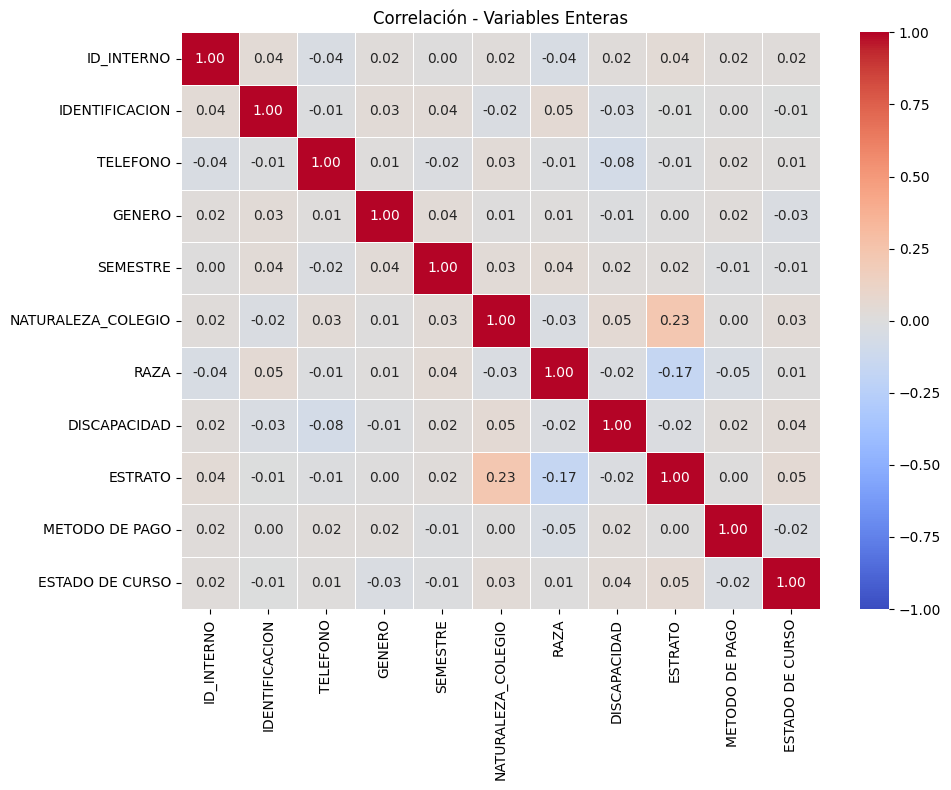

In [6]:
# Seleccionar SOLO columnas int
df_int = df.select_dtypes(include='int64')

print("Columnas incluidas:", df_int.columns.tolist())  # Verificar qué columnas quedaron

# Graficar
plt.figure(figsize=(10, 8))
sns.heatmap(df_int.corr(), 
            annot=True, 
            fmt=".2f", 
            cmap="coolwarm",
            vmin=-1, vmax=1,
            linewidths=0.5)

plt.title("Correlación - Variables Enteras")
plt.tight_layout()
plt.show()